{'topic': '猫咪', 'poem': '## 《午后睡猫》\n\n我曾见过\n最纯粹的沉迷\n当它蜷成\n一截温暖的毛球\n晨光在绒毛间\n碎成金粉\n\n世界在窗外\n变得圆润而遥远\n它的胡须偶尔抖动\n像在测量\n梦的深度\n\n忽然间\n一道光划破地板\n它扑向虚影\n又坐回优雅的姿态\n尾巴尖画出\n最完美的弧度\n\n黄昏降临时\n它溜进幽暗的门缝\n我才知道\n所有的好奇\n都是对时间\n温柔的试探\n每一次追逐\n都在丈量光的痕迹\n而每次驻足\n都让空茫的午后\n被光的流逝\n温柔地填满', 'content_type': '诗'}
{'topic': '猫咪', 'joke': '我来讲一个：\n\n有只猫走进了一家狗狗酒吧，坐在吧台边，淡定地对酒保说：“给我来一碗牛奶。”\n\n酒保（一只金毛）愣住了，说：“呃……这位客人，这里是狗狗酒吧，我们只接待狗狗。”\n\n猫慢悠悠地舔了舔爪子：“我知道。”\n\n酒保更迷惑了：“那你还来？”\n\n猫叹了口气：“因为全城的狗狗都在这里，我想找一只狗，问问它到底为什么那么爱追我。”\n\n酒保松了一口气，笑着问：“那你找到答案了吗？”\n\n猫端起牛奶（金毛还是偷偷给了），喝了一口，淡淡地说：“找到了。他说，因为我跑起来的样子像一块移动的鸡腿。”', 'content_type': '笑话'}


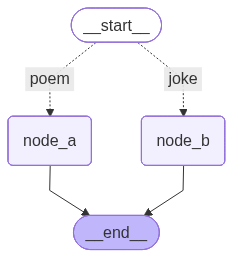

In [4]:
from typing import TypedDict,Literal
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thingking":{
            "type":"disabled"
        }
    }
)

#1. 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str

#2. 定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"写一首关于{state['topic']}主题的诗"]).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"写一个关于{state['topic']}主题的笑话"]).content
    return {
        "joke": joke
    }

def my_route(state: OverAllState) -> Literal["poem","joke"]:
    if "诗" in state["content_type"]:
        return "poem"
    else:
        return "joke"


#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_conditional_edges(START,my_route,path_map={
    "poem":"node_a",
    "joke":"node_b"
})
builder.add_edge("node_b",END)
builder.add_edge("node_a",END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "猫咪","content_type":"诗"})
print(poem_res)

joke_res = graph.invoke({"topic": "猫咪","content_type":"笑话"})
print(joke_res)

from IPython.display import display
display(graph)
